# CardioIA — Fase 2 (Parte 2): triagem textual com TF-IDF

Classificação de frases em **baixo risco** e **alto risco** com `TfidfVectorizer` e regressão logística (`scikit-learn`).

**Aviso:** exercício acadêmico com dados simulados; **não** constitui triagem ou diagnóstico médico.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

NOTEBOOK_DIR = Path.cwd()
FASE2 = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else Path("fase2")
CSV_PATH = FASE2 / "dados" / "frases_risco_triagem.csv"

df = pd.read_csv(CSV_PATH)
df["frase"] = df["frase"].astype(str).str.strip()
df["situacao"] = df["situacao"].astype(str).str.strip().str.lower()

assert set(df["situacao"].unique()) <= {"baixo risco", "alto risco"}
df.head()

,frase,situacao
0,sinto um leve desconforto nas costas ao acorda...,baixo risco
1,percebi batimentos um pouco mais rapidos depoi...,baixo risco
2,caminhei vinte minutos sem falta de ar nem dor...,baixo risco
3,"tenho leve cansaco no fim do dia, mas durmo be...",baixo risco
4,sinto um puxadinho muscular no braco apos musc...,baixo risco


## Vetorização TF-IDF e divisão treino/teste

Usamos `ngram_range=(1, 2)` para capturar expressões como *falta de ar*.

In [2]:
X = df["frase"]
y = df["situacao"]

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape

((54, 793), (18, 793))

## Modelo e métricas no conjunto de teste

Acurácia (teste): 0.944
              precision    recall  f1-score   support

  alto risco      1.000     0.889     0.941         9
 baixo risco      0.900     1.000     0.947         9

    accuracy                          0.944        18
   macro avg      0.950     0.944     0.944        18
weighted avg      0.950     0.944     0.944        18



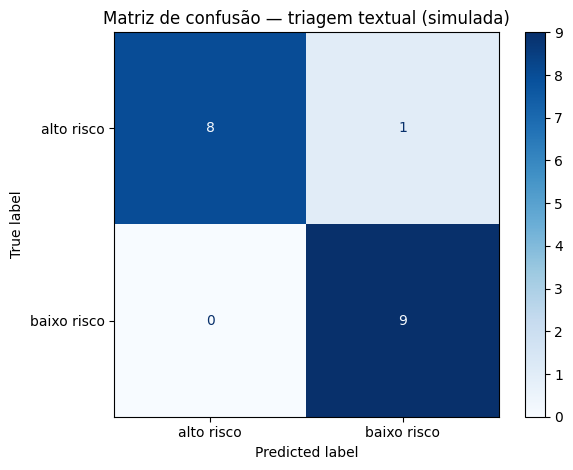

In [3]:
clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia (teste): {acc:.3f}")
print(classification_report(y_test, y_pred, digits=3))

labels = ["alto risco", "baixo risco"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", cmap="Blues")
plt.title("Matriz de confusão — triagem textual (simulada)")
plt.tight_layout()
plt.show()

## Testes manuais (frases novas / ambíguas)

Incluímos casos na fronteira entre linguagem levemente ansiosa e sintomas mais alarmantes.

In [4]:
novas = [
    "sinto um aperto leve no peito ao me preocupar, sem irradiacao ou suor",
    "tenho dor no peito com falta de ar em repouso e sensacao de morte iminente",
    "fiz caminhada leve no parque sem dor nem falta de ar",
    "apresento palpitacoes isoladas apos cafe, sem dor toracica",
    "sinto falta de ar subita com dor pleuritica e febre alta",
]

X_novas = vectorizer.transform(novas)
preds = clf.predict(X_novas)
probas = clf.predict_proba(X_novas)

for texto, pred, prob in zip(novas, preds, probas):
    p_alto = prob[list(clf.classes_).index("alto risco")]
    trecho = texto if len(texto) <= 100 else texto[:100] + "..."
    print(f"\nFrase: {trecho}")
    print(f"  Predição: {pred}  (P(alto risco)={p_alto:.3f})")


Frase: sinto um aperto leve no peito ao me preocupar, sem irradiacao ou suor
  Predição: baixo risco  (P(alto risco)=0.382)

Frase: tenho dor no peito com falta de ar em repouso e sensacao de morte iminente
  Predição: alto risco  (P(alto risco)=0.668)

Frase: fiz caminhada leve no parque sem dor nem falta de ar
  Predição: baixo risco  (P(alto risco)=0.406)

Frase: apresento palpitacoes isoladas apos cafe, sem dor toracica
  Predição: baixo risco  (P(alto risco)=0.479)

Frase: sinto falta de ar subita com dor pleuritica e febre alta
  Predição: alto risco  (P(alto risco)=0.636)


## Reflexão: viés, governança e limitações

- **Amostra pequena e artificial:** 72 frases simuladas não representam a diversidade real de queixas, dialetos ou gravidade clínica; a acurácia no teste tende a ser otimista se o vocabulário de treino e teste for muito parecido.
- **Rótulos subjetivos:** *alto* e *baixo risco* foram definidos pela equipe por heurística textual, não por critério médico validado; outro rotulador poderia discordar, especialmente em frases ambíguas.
- **Viés lexical:** TF-IDF + regressão logística pode aprender espúriamente que certas palavras (ex.: *dor no peito*) correlacionam com *alto risco* neste CSV, sem garantir que isso generalize para novos relatos ou populações; há risco de **falsos positivos** ou **falsos negativos** em produção.
- **Uso em produção:** sistemas reais exigem validação clínica, monitoramento de deriva de dados, transparência (explicabilidade), conformidade regulatória e fluxo humano na decisão — este notebook é apenas um protótipo educacional.

**Conexão com a Fase 1:** o `dataset_cardiovascular.csv` da Fase 1 é sintético e ilustra como dados de origem e qualidade impactam modelos; aqui o mesmo princípio vale para **texto rotulado**: a governança começa na definição honesta do que entra na base e em como os rótulos foram construídos.